833.2916666666666
Problem files: []
Duplicates dropped: 0
Len of df after dropping duplicates: 39998
Number of unique TICs: 953

Removing 0 rows with missing stellar mass
Dataframe size after removal: 2058 rows
False positive cells: 18


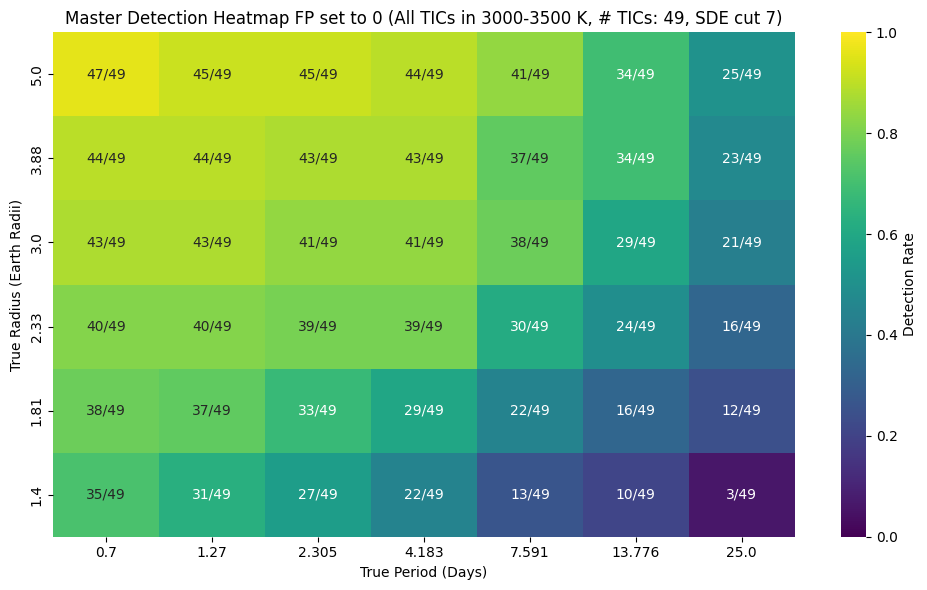

Removing 0 rows with missing stellar mass
Dataframe size after removal: 3570 rows
False positive cells: 36


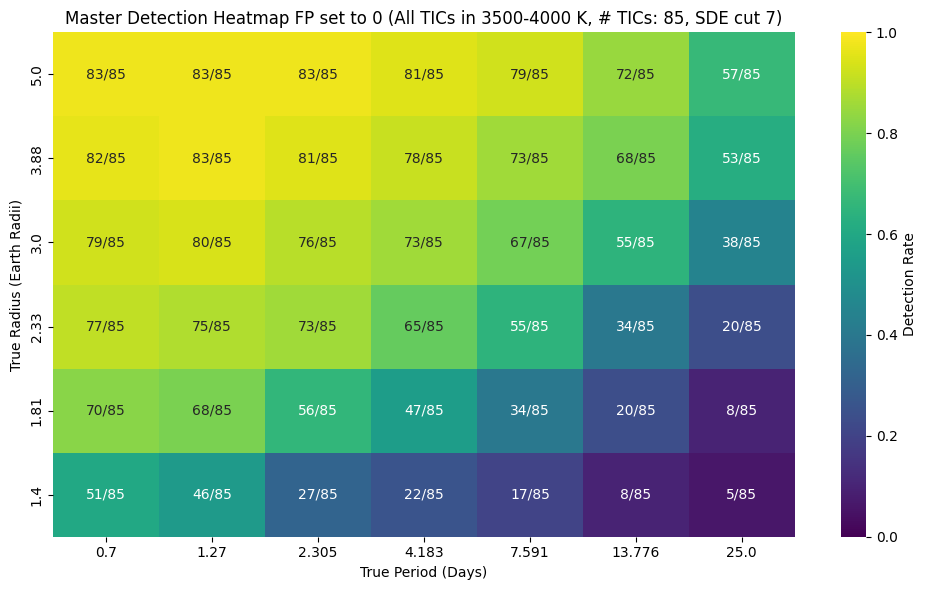

Removing 0 rows with missing stellar mass
Dataframe size after removal: 2772 rows
False positive cells: 48


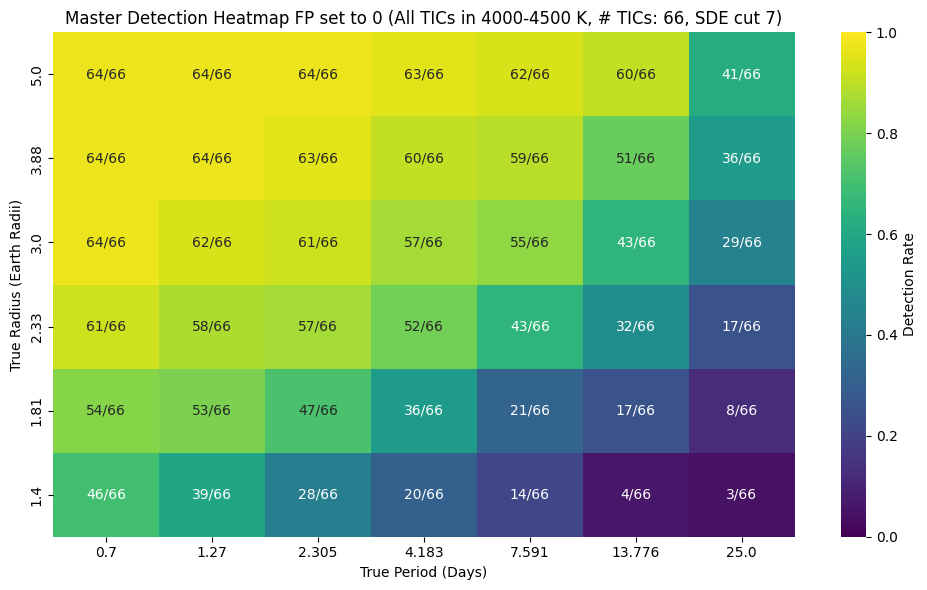

Removing 0 rows with missing stellar mass
Dataframe size after removal: 4788 rows
False positive cells: 54


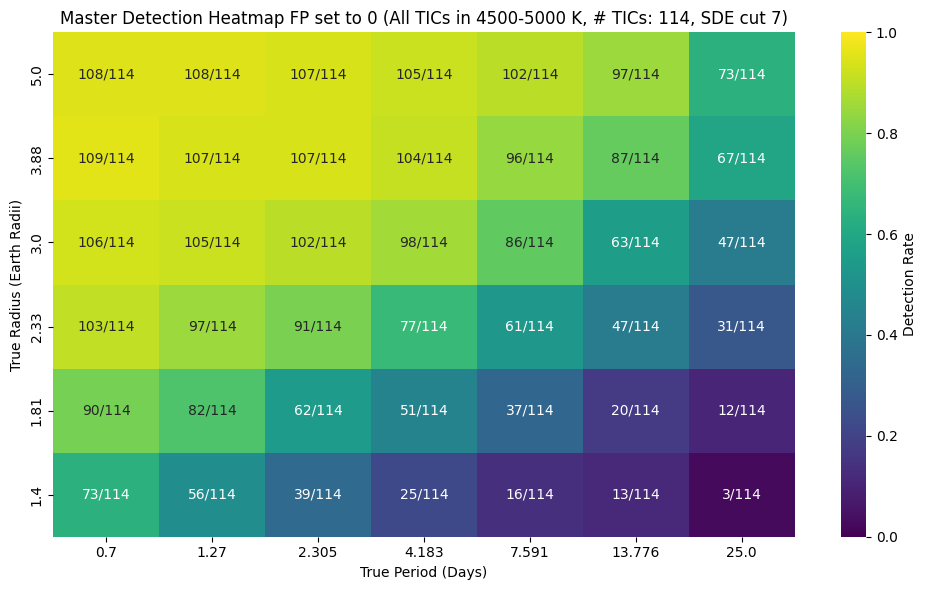

Removing 0 rows with missing stellar mass
Dataframe size after removal: 7896 rows
False positive cells: 102


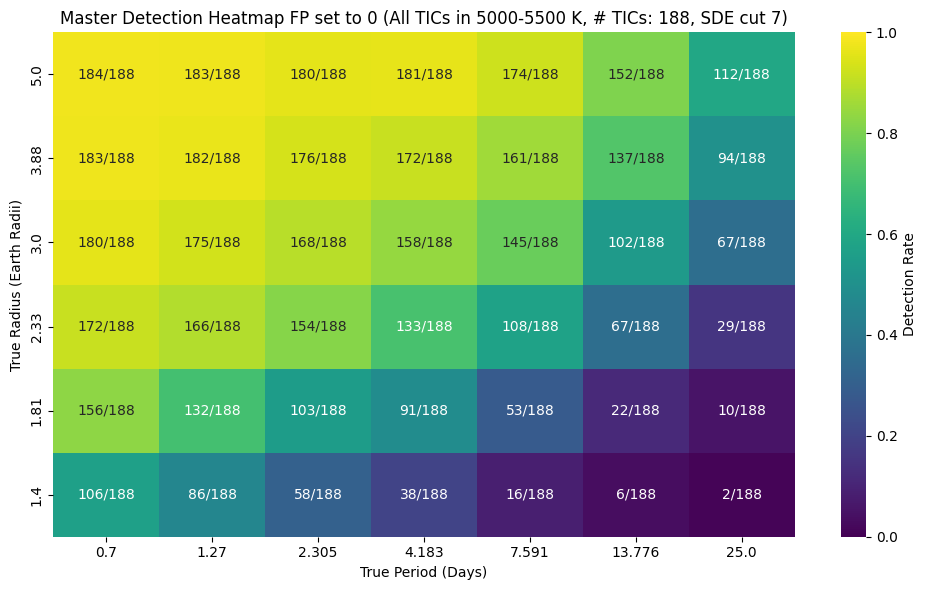

Removing 0 rows with missing stellar mass
Dataframe size after removal: 9758 rows
False positive cells: 120


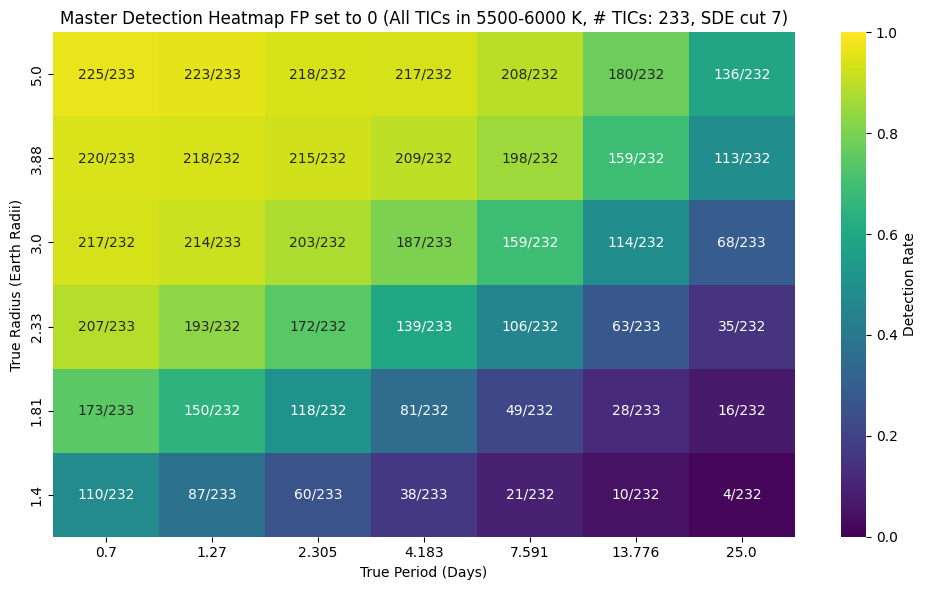

Removing 0 rows with missing stellar mass
Dataframe size after removal: 6384 rows
False positive cells: 48


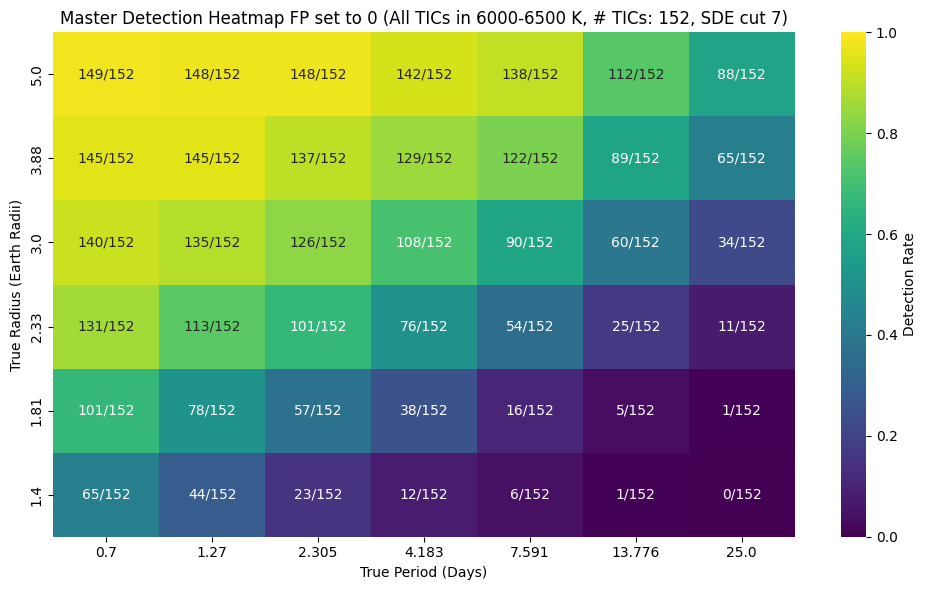

Removing 0 rows with missing stellar mass
Dataframe size after removal: 1344 rows
False positive cells: 12


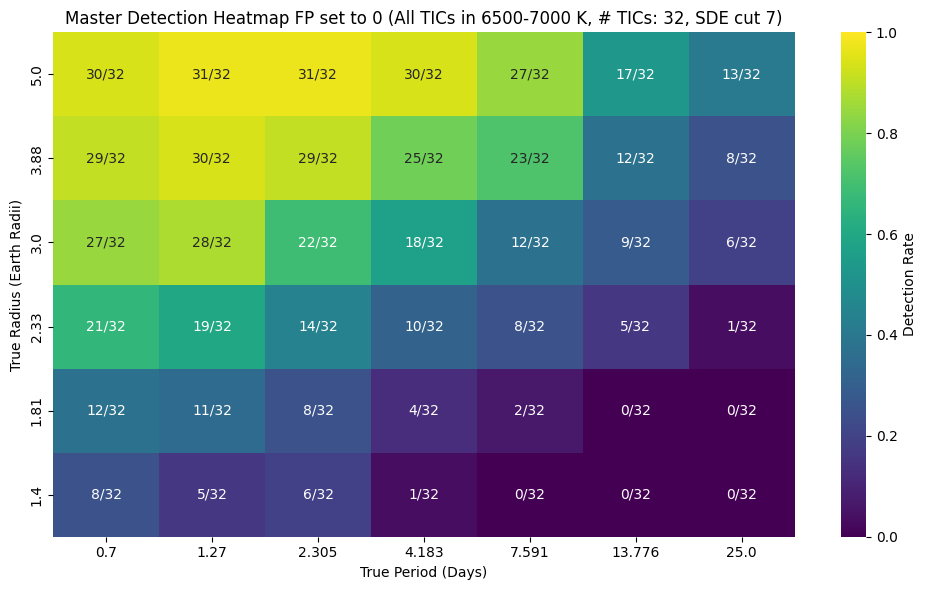

In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def calc_geometric_transit_probability(df):
    # Cross-match with CTL.csv to add stellar mass
    ctl_df = pd.read_csv('./stellar_params_CTL.csv')
    df = df.copy()

    # Clean TIC column in both dataframes to ensure matching
    df['TIC_clean'] = df['TIC'].str.replace('TIC ', '')
    ctl_df['TIC_clean'] = ctl_df['id'].astype(str).str.replace('TIC ', '')

    # Merge to add stellar mass
    df = df.merge(
        ctl_df[['TIC_clean', 'MASS']], 
        on='TIC_clean', 
        how='left'
    ).rename(columns={'MASS': 'Stellar Mass'})

    # Drop the temporary TIC_clean column
    df = df.drop('TIC_clean', axis=1)
    #print(df)


    # Check for missing stellar masses and remove them
    missing_mass = df['Stellar Mass'].isna().sum()
    print(f"Removing {missing_mass} rows with missing stellar mass")
    df = df.dropna(subset=['Stellar Mass'])
    print(f"Dataframe size after removal: {len(df)} rows")

    # Calculate transit probability using actual stellar mass (vectorized)
    R_star = df['Stellar Radius'] * 6.96e8  # Solar radii to meters
    R_planet = df['True Radius (Earth Radii)'] * 6.378e6  # Earth radii to meters
    P = df['True Period (Days)'] * 86400  # Days to seconds
    M_star = df['Stellar Mass'] * 1.989e30  # Solar masses to kg
    G = 6.67430e-11  # Gravitational constant in m³/(kg·s²)

    a = ((P**2 * G * M_star) / (4 * np.pi**2))**(1/3)  # Semi-major axis in meters
    df['Transit Probability'] = (R_star + R_planet) / a
    return df

def filter_out_false_positives(df, sde_threshold):
    false_positive_df = pd.read_csv('/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/gen_heatmaps/rec_only/rec_results/CTL_TLS_recovery.csv')

    rows_to_keep = []
    false_positive_count = 0


    for idx, row in df.iterrows():
        tic = row['TIC']
        true_period = float(row['True Period (Days)'])
        
        # Check if this TIC exists in false positives data
        fp_row = false_positive_df[false_positive_df['TIC'] == tic]
        
        is_false_positive = False
        
        # If we found matching TIC in false positive data
        if len(fp_row) > 0:
            try:
                # Parse false positive periods and SDE arrays
                fp_periods = fp_row['TLS Periods array'].iloc[0].replace('[', '').replace(']', '').split()
                fp_periods = [float(p) for p in fp_periods]
                fp_sde = fp_row['TLS SDE > 7 array'].iloc[0].replace('[', '').replace(']', '').split()
                fp_sde = [float(s) for s in fp_sde]
                
                # Get periods above threshold from false positives
                fp_periods_above_threshold = [p for p, s in zip(fp_periods, fp_sde) if s > sde_threshold]
                
                # Check if any false positive periods match our true period or its aliases
                aliases = [true_period, true_period/2, true_period*2, true_period/3, true_period*3]
                is_false_positive = any(0.999 * alias < fp_p < 1.001 * alias 
                                    for fp_p in fp_periods_above_threshold 
                                    for alias in aliases)

                # SET TO 0 method
                if any(any(0.999 * alias < fp_p < 1.001 * alias for alias in aliases) for fp_p in fp_periods_above_threshold):
                    df.loc[idx, 'TLS Periods array'] = '[]'
                    df.loc[idx, 'TLS SDE > 7 array'] = '[]'
                    false_positive_count +=1
                #print(f"TIC {tic}: is_false_positive = {is_false_positive}")
            except:
                pass
        
        # Keep the row only if it's NOT a false positive
        if is_false_positive == False:
            rows_to_keep.append(idx)

            ##SET TO 0 method
        elif is_false_positive == True:
            rows_to_keep.append(idx)



    # Filter the dataframe
    df_filtered = df.loc[rows_to_keep].reset_index(drop=True)

    #print(f"Original rows: {len(df)}")
    #print(f"Rows after filtering false positives: {len(df_filtered)}")
    print(f"False positive cells: {false_positive_count}")

    # Replace df with the filtered version
    return df_filtered

def transit_probability_heatmap(df, temp_range):
    # temp_range should be like (3000, 3500)
    temp_min, temp_max = temp_range

    # Filter based on Stellar Temperature
    temp_lim = (df['Stellar Temperature'] >= temp_min) & (df['Stellar Temperature'] <= temp_max)
    df = df[temp_lim].copy()

    #########################
    df = calc_geometric_transit_probability(df)
    ########################

    unique_tics = df['TIC'].unique()

    # Collect all transit probability results here
    all_transit_rows = []

    for tic in unique_tics:
        try:
            tic_rows = df[df['TIC'] == tic]
            if tic_rows['True Radius (Earth Radii)'].isnull().all():
                continue

            for _, row in tic_rows.iterrows():
                all_transit_rows.append({
                    'True Radius (Earth Radii)': row['True Radius (Earth Radii)'],
                    'True Period (Days)': row['True Period (Days)'],
                    'Transit Probability': row['Transit Probability']
                })

        except Exception as e:
            print(f"An error for TIC {tic} occurred: {e}")
            continue

    if all_transit_rows:
        transit_df = pd.DataFrame(all_transit_rows)

        # Group by radius and period, average transit probabilities
        transit_counts = transit_df.groupby(
            ['True Radius (Earth Radii)', 'True Period (Days)']
        ).agg(
            avg_transit_prob=('Transit Probability', 'mean'),
            count=('Transit Probability', 'count')
        ).reset_index()

        # Pivot for heatmap
        transit_pivot = transit_counts.pivot(
            index='True Radius (Earth Radii)',
            columns='True Period (Days)',
            values='avg_transit_prob'
        )

        # Create annotation matrix showing transit probability values
        annot_matrix = transit_counts.pivot(
            index='True Radius (Earth Radii)',
            columns='True Period (Days)',
            values='avg_transit_prob'
        ).round(4)  # Round to 4 decimal places for readability

        plt.figure(figsize=(10, 6))
        sns.heatmap(
            transit_pivot,
            annot=annot_matrix,
            fmt='.4f',  # Display transit probability values with 4 decimal places
            cmap='plasma',
            cbar_kws={'label': 'Average Transit Probability'},
            vmin=0, vmax=transit_pivot.max().max()
        )
        plt.gca().invert_yaxis()
        plt.title(f'Transit Probability Heatmap ({temp_min}-{temp_max} K, # TICs: {len(unique_tics)})')
        plt.xlabel('True Period (Days)')
        plt.ylabel('True Radius (Earth Radii)')
        plt.tight_layout()
        plt.show()

        # output_dir = './master_heatmaps/'
        # os.makedirs(output_dir, exist_ok=True)
        # output_filename = f'geometry_heatmap_{temp_min}_{temp_max}_K_sde_{sde_threshold}_tics_{len(unique_tics)}.csv'
        # transit_counts.to_csv(os.path.join(output_dir, output_filename), index=False)

    else:
        print("No valid data to generate transit probability heatmap.")


def master_heatmap(df, sde_threshold, temp_range):
    # temp_range should be like "3000-3500" or (3000, 3500)
    temp_min, temp_max = temp_range

    # Filter based on Stellar Temperature
    temp_lim = (df['Stellar Temperature'] >= temp_min) & (df['Stellar Temperature'] <= temp_max)
    df = df[temp_lim]

    #########################
    #this removes rows with missing stellar mass
    df = calc_geometric_transit_probability(df)

    df = filter_out_false_positives(df, sde_threshold)
    ########################

    unique_tics = df['TIC'].unique()
    #print(len(unique_tics))

    # Collect all detection results here
    all_heatmap_rows = []

    for tic in unique_tics:
        try:
            tic_rows = df[df['TIC'] == tic]
            if tic_rows['True Radius (Earth Radii)'].isnull().all():
                print(f"No valid data for {tic}, skipping...")
                continue

            for _, row in tic_rows.iterrows():
                true_period = float(row['True Period (Days)'])

                try:
                    periods = row['TLS Periods array'].replace('[', '').replace(']', '').split()
                    sdes = row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()
                    periods = [float(p) for p in periods]
                    sdes = [float(s) for s in sdes]
                except:
                    continue

                # Periods with SDE above threshold
                periods_above_threshold = [
                    p for p, s in zip(periods, sdes) if s > sde_threshold
                ]
                # Include aliases (harmonics) for detection check
                aliases = [true_period, true_period / 2, true_period * 2, true_period / 3, true_period * 3]

                detected = any(
                    0.999 * alias < p < 1.001 * alias
                    for alias in aliases
                    for p in periods_above_threshold
                )

                all_heatmap_rows.append({
                    'True Radius (Earth Radii)': row['True Radius (Earth Radii)'],
                    'True Period (Days)': row['True Period (Days)'],
                    'Detection': int(detected),
                    'Transit Probability': row['Transit Probability']
                })

        except Exception as e:
            print(f"An error for TIC {tic} occurred: {e}")
            continue

    if all_heatmap_rows:
        heatmap_df = pd.DataFrame(all_heatmap_rows)
        heatmap_df['Detection'] = pd.to_numeric(heatmap_df['Detection'])

        # Group by radius and period, count detections and trials
        heatmap_counts = heatmap_df.groupby(
            ['True Radius (Earth Radii)', 'True Period (Days)']
        ).agg(
            detections=('Detection', 'sum'),
            trials=('Detection', 'count'),
            transit_prob= ('Transit Probability', 'mean')
        ).reset_index()

        # Calculate detection rate for coloring
        heatmap_counts['detection_rate'] = heatmap_counts['detections'] / heatmap_counts['trials']
        #print(heatmap_counts)
        # Pivot for heatmap coloring
        heatmap_pivot = heatmap_counts.pivot(
            index='True Radius (Earth Radii)',
            columns='True Period (Days)',
            values='detection_rate'
        )

        # Create annotation matrix as "detections/trials"
        annot_matrix = heatmap_counts.pivot(
            index='True Radius (Earth Radii)',
            columns='True Period (Days)',
            values='detections'
        ).astype(str) + "/" + heatmap_counts.pivot(
            index='True Radius (Earth Radii)',
            columns='True Period (Days)',
            values='trials'
        ).astype(str)

        avg_detected_radius = heatmap_df.loc[heatmap_df['Detection'] == 1, 'True Radius (Earth Radii)'].mean()
        #print(f"Average radius of detected planets for SDE cut {sde_threshold} "
        #      f"and Stellar Temp range {temp_min}-{temp_max} K: {avg_detected_radius:.3f} Earth radii")

        plt.figure(figsize=(10, 6))
        sns.heatmap(
            heatmap_pivot,
            annot=annot_matrix,
            fmt='',  # Display annotations as given
            cmap='viridis',
            cbar_kws={'label': 'Detection Rate'},
            vmin=0, vmax=1
        )
        plt.gca().invert_yaxis()
        plt.title(f'Master Detection Heatmap FP set to 0 (All TICs in {temp_min}-{temp_max} K, # TICs: {len(unique_tics)}, SDE cut {sde_threshold})')
        plt.xlabel('True Period (Days)')
        plt.ylabel('True Radius (Earth Radii)')
        plt.tight_layout()
        plt.show()

        #save to csv
        output_dir = './master_heatmaps/'
        os.makedirs(output_dir, exist_ok=True)
        output_filename = f'master_heatmap_{temp_min}_{temp_max}_K_sde_{sde_threshold}.csv'
        heatmap_counts.to_csv(os.path.join(output_dir, output_filename), index=False)

    else:
        print("No valid data to generate master heatmap.")


#csv_files = glob.glob("./bf_sep_22_tls_results_per_tic/*.csv")
#csv_files = glob.glob("./bf_oct13_tls_results_per_tic/*.csv")
csv_files = glob.glob("./tls_results_per_tic/*")
print(len(csv_files)/48) #WHY DIFFERENT #??

##############

############## COLLECT BROKEN FILES ##################
problem_files = []
for f in csv_files:
    try:
        pd.read_csv(f, engine="python")
        
    except Exception as e:
        print(f"Problem reading {f}: {e}")
        problem_files.append(f)
print("Problem files:", problem_files)
csv_files = [f for f in csv_files if f not in problem_files]
#######################################################

df_list = [pd.read_csv(f) for f in csv_files]


df = pd.concat(df_list, ignore_index=True)
df = df[['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', 'Detection', '# trials', 'TLS Periods array', 'TLS SDE > 7 array', 'Stellar Radius', 'Stellar Temperature']]
before = len(df)
df = df.drop_duplicates(subset=['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', '# trials'])
after = len(df)
print(f"Duplicates dropped: {before - after}")
print(f'Len of df after dropping duplicates: {len(df)}')

unique_tics = df['TIC'].unique()
print(f"Number of unique TICs: {len(unique_tics)}\n")

sde_threshold = 7
temp_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]#, (7000,8000)]
#temp_ranges = [(3000,7000)]

for temp_range in temp_ranges:
    master_heatmap(df, sde_threshold, temp_range)

    

Detection Rate Pivot Table for master_heatmap_4000_4500_K_sde_7.csv:
True Period (Days)           0.700     1.270     2.305     4.183     7.591   \
True Radius (Earth Radii)                                                     
1.40                       0.709091  0.600000  0.436364  0.327273  0.200000   
1.81                       0.854545  0.836364  0.727273  0.563636  0.309091   
2.33                       0.945455  0.909091  0.909091  0.836364  0.654545   
3.00                       0.981818  0.963636  0.945455  0.909091  0.854545   
3.88                       0.981818  0.981818  0.963636  0.963636  0.909091   
5.00                       0.981818  0.981818  0.981818  0.981818  0.963636   

True Period (Days)           13.776    25.000  
True Radius (Earth Radii)                      
1.40                       0.072727  0.054545  
1.81                       0.254545  0.127273  
2.33                       0.509091  0.254545  
3.00                       0.690909  0.454545  
3.88      

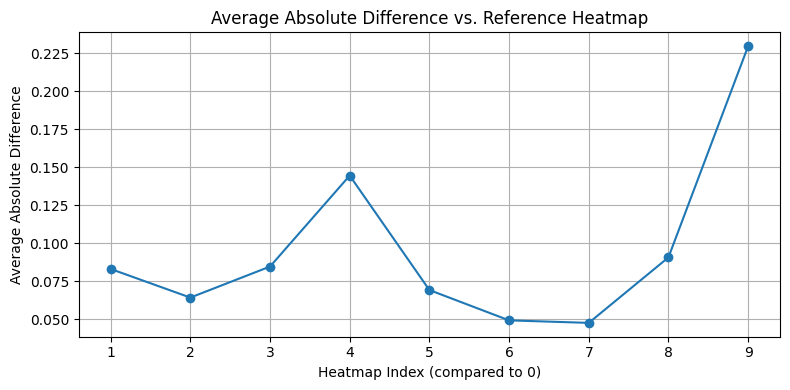

In [24]:
import glob as glob
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load all master heatmap CSVs generated in the previous cell
master_heatmap_files = glob.glob('./master_heatmaps/master_heatmap_*_K_sde_*.csv')
#rint(f"Found {len(master_heatmap_files)} master heatmap files.")

# Read each heatmap into a list of DataFrames
heatmaps = [pd.read_csv(f) for f in master_heatmap_files]

# Optionally, print the filenames and shapes for verification
#for f, hm in zip(master_heatmap_files, heatmaps):
   # print(f"{os.path.basename(f)}: shape {hm.shape}")

# Plot detection rate heatmap for each loaded DataFrame
# for i, hm in enumerate(heatmaps):
#     pivot = hm.pivot(index='True Radius (Earth Radii)', columns='True Period (Days)', values='detection_rate')
#     plt.figure(figsize=(8, 5))
#     sns.heatmap(pivot, annot=False, cmap='viridis', vmin=0, vmax=1, cbar_kws={'label': 'Detection Rate'})
#     plt.gca().invert_yaxis()
#     plt.title(f"Detection Rate Heatmap\n{os.path.basename(master_heatmap_files[i])}")
#     plt.xlabel('True Period (Days)')
#     plt.ylabel('True Radius (Earth Radii)')
#     plt.tight_layout()
#     plt.show()
    # Print the DataFrames in the same format as the histograms (pivot tables)
for i, hm in enumerate(heatmaps):
    pivot = hm.pivot(index='True Radius (Earth Radii)', columns='True Period (Days)', values='detection_rate')
    print(f"Detection Rate Pivot Table for {os.path.basename(master_heatmap_files[i])}:")
    print(pivot)
    print("\n")

# Compare all heatmap pivots to the first one (pivot1) and print average absolute differences
def average_difference(df1, df2):
    # Align indices and columns
    df1, df2 = df1.align(df2, join='inner')
    # Flatten and drop NaNs in both
    mask = (~df1.isna()) & (~df2.isna())
    diffs = (df1[mask] - df2[mask]).abs()
    return diffs.values.mean()

pivot1 = heatmaps[0].pivot(index='True Radius (Earth Radii)', columns='True Period (Days)', values='detection_rate')
for idx, hm in enumerate(heatmaps[1:], start=1):
    pivot2 = hm.pivot(index='True Radius (Earth Radii)', columns='True Period (Days)', values='detection_rate')
    avg_diff = average_difference(pivot1, pivot2)
    print(f"Average absolute difference between heatmap 0 and {idx}: {avg_diff:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(avg_diffs) + 1), avg_diffs, marker='o')
plt.xlabel('Heatmap Index (compared to 0)')
plt.ylabel('Average Absolute Difference')
plt.title('Average Absolute Difference vs. Reference Heatmap')
plt.grid(True)
plt.tight_layout()
plt.show()